# Data Cleaning File
The aim is to download a dataset, study the variables and the completeness of the data, and identify which variables can already be eliminated at this stage as unsuitable for machine learning modelling.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# a function for categorical variables visual
def barplot_h(Series, Title=''):
    plt.title(Title)
    Series.value_counts().plot.barh()
    plt.show()

## 1. Dataset Upload

In [3]:
data = pd.read_csv('LoanTap Data.csv')

In [4]:
data.head()

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,...,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,application_type,mort_acc,pub_rec_bankruptcies,address
0,10000.0,36 months,11.44,329.48,B,B4,Marketing,10+ years,RENT,117000.0,...,16.0,0.0,36369.0,41.8,25.0,w,INDIVIDUAL,0.0,0.0,"0174 Michelle Gateway\r\nMendozaberg, OK 22690"
1,8000.0,36 months,11.99,265.68,B,B5,Credit analyst,4 years,MORTGAGE,65000.0,...,17.0,0.0,20131.0,53.3,27.0,f,INDIVIDUAL,3.0,0.0,"1076 Carney Fort Apt. 347\r\nLoganmouth, SD 05113"
2,15600.0,36 months,10.49,506.97,B,B3,Statistician,< 1 year,RENT,43057.0,...,13.0,0.0,11987.0,92.2,26.0,f,INDIVIDUAL,0.0,0.0,"87025 Mark Dale Apt. 269\r\nNew Sabrina, WV 05113"
3,7200.0,36 months,6.49,220.65,A,A2,Client Advocate,6 years,RENT,54000.0,...,6.0,0.0,5472.0,21.5,13.0,f,INDIVIDUAL,0.0,0.0,"823 Reid Ford\r\nDelacruzside, MA 00813"
4,24375.0,60 months,17.27,609.33,C,C5,Destiny Management Inc.,9 years,MORTGAGE,55000.0,...,13.0,0.0,24584.0,69.8,43.0,f,INDIVIDUAL,1.0,0.0,"679 Luna Roads\r\nGreggshire, VA 11650"


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 396030 entries, 0 to 396029
Data columns (total 27 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   loan_amnt             396030 non-null  float64
 1   term                  396030 non-null  object 
 2   int_rate              396030 non-null  float64
 3   installment           396030 non-null  float64
 4   grade                 396030 non-null  object 
 5   sub_grade             396030 non-null  object 
 6   emp_title             373103 non-null  object 
 7   emp_length            377729 non-null  object 
 8   home_ownership        396030 non-null  object 
 9   annual_inc            396030 non-null  float64
 10  verification_status   396030 non-null  object 
 11  issue_d               396030 non-null  object 
 12  loan_status           396030 non-null  object 
 13  purpose               396030 non-null  object 
 14  title                 394274 non-null  object 
 15  

## 2. Null Values Variables
Some of the variables - *emp_title*, *emp_length*, *title*, *revol_util*, *mort_acc* - contain *Null* values. I want to estimate the potential data loss if I delete the rows with null values from the dataset.

In [6]:
data[data['emp_title'].isna()]

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,...,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,application_type,mort_acc,pub_rec_bankruptcies,address
35,5375.0,36 months,13.11,181.39,B,B4,NaN,NaN,RENT,34000.00,...,9.0,1.0,14998.0,88.7,20.0,f,INDIVIDUAL,5.0,1.0,"23617 Michael Viaduct\r\nWest John, MS 05113"
36,3250.0,36 months,16.78,115.52,C,C5,NaN,NaN,RENT,22500.00,...,7.0,0.0,7587.0,54.6,7.0,f,INDIVIDUAL,0.0,0.0,"361 Erica Forest\r\nLake Mariaton, TN 30723"
40,35000.0,60 months,16.99,869.66,D,D1,NaN,4 years,MORTGAGE,130000.00,...,10.0,0.0,34130.0,53.8,27.0,f,INDIVIDUAL,10.0,0.0,"8268 Reed Gardens Suite 996\r\nEast Johnmouth,..."
49,15000.0,36 months,7.89,469.29,A,A5,NaN,NaN,MORTGAGE,90000.00,...,7.0,0.0,8205.0,93.2,18.0,w,INDIVIDUAL,6.0,0.0,"84009 David Stream\r\nSouth Nicolehaven, IL 05113"
58,10000.0,36 months,17.56,359.33,D,D1,NaN,NaN,MORTGAGE,32000.00,...,6.0,0.0,11615.0,82.4,7.0,w,INDIVIDUAL,0.0,0.0,"965 Spencer Courts\r\nPacetown, AZ 00813"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395946,35000.0,60 months,16.20,854.86,C,C4,NaN,NaN,MORTGAGE,84000.00,...,7.0,0.0,4241.0,18.8,21.0,w,INDIVIDUAL,5.0,0.0,"2645 Wayne Street\r\nMarymouth, HI 22690"
395963,7000.0,36 months,20.20,260.86,E,E3,NaN,NaN,OWN,32964.00,...,24.0,1.0,3236.0,9.7,44.0,w,INDIVIDUAL,0.0,1.0,8339 Daniel Forges Suite 273\r\nPort Oscarmout...
395988,35000.0,60 months,15.59,843.53,D,D1,NaN,NaN,OWN,102396.00,...,15.0,0.0,31665.0,32.4,33.0,w,INDIVIDUAL,1.0,0.0,"114 Sonya Pass\r\nCarlamouth, SD 00813"
395999,11125.0,36 months,24.11,437.11,F,F2,NaN,NaN,MORTGAGE,31789.88,...,8.0,0.0,22385.0,81.0,24.0,w,INDIVIDUAL,4.0,0.0,"1314 Bridget Terrace\r\nRebeccashire, NE 30723"


In [7]:
data[data['emp_length'].isna()]

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,...,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,application_type,mort_acc,pub_rec_bankruptcies,address
35,5375.0,36 months,13.11,181.39,B,B4,NaN,NaN,RENT,34000.00,...,9.0,1.0,14998.0,88.7,20.0,f,INDIVIDUAL,5.0,1.0,"23617 Michael Viaduct\r\nWest John, MS 05113"
36,3250.0,36 months,16.78,115.52,C,C5,NaN,NaN,RENT,22500.00,...,7.0,0.0,7587.0,54.6,7.0,f,INDIVIDUAL,0.0,0.0,"361 Erica Forest\r\nLake Mariaton, TN 30723"
49,15000.0,36 months,7.89,469.29,A,A5,NaN,NaN,MORTGAGE,90000.00,...,7.0,0.0,8205.0,93.2,18.0,w,INDIVIDUAL,6.0,0.0,"84009 David Stream\r\nSouth Nicolehaven, IL 05113"
58,10000.0,36 months,17.56,359.33,D,D1,NaN,NaN,MORTGAGE,32000.00,...,6.0,0.0,11615.0,82.4,7.0,w,INDIVIDUAL,0.0,0.0,"965 Spencer Courts\r\nPacetown, AZ 00813"
91,30225.0,60 months,18.24,771.47,D,D5,NaN,NaN,MORTGAGE,65800.00,...,11.0,0.0,14390.0,69.5,31.0,w,INDIVIDUAL,1.0,0.0,"493 Michael Route\r\nHillfurt, AZ 70466"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395946,35000.0,60 months,16.20,854.86,C,C4,NaN,NaN,MORTGAGE,84000.00,...,7.0,0.0,4241.0,18.8,21.0,w,INDIVIDUAL,5.0,0.0,"2645 Wayne Street\r\nMarymouth, HI 22690"
395963,7000.0,36 months,20.20,260.86,E,E3,NaN,NaN,OWN,32964.00,...,24.0,1.0,3236.0,9.7,44.0,w,INDIVIDUAL,0.0,1.0,8339 Daniel Forges Suite 273\r\nPort Oscarmout...
395988,35000.0,60 months,15.59,843.53,D,D1,NaN,NaN,OWN,102396.00,...,15.0,0.0,31665.0,32.4,33.0,w,INDIVIDUAL,1.0,0.0,"114 Sonya Pass\r\nCarlamouth, SD 00813"
395999,11125.0,36 months,24.11,437.11,F,F2,NaN,NaN,MORTGAGE,31789.88,...,8.0,0.0,22385.0,81.0,24.0,w,INDIVIDUAL,4.0,0.0,"1314 Bridget Terrace\r\nRebeccashire, NE 30723"


In [8]:
data[data['revol_util'].isna()]

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,...,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,application_type,mort_acc,pub_rec_bankruptcies,address
1686,2150.0,36 months,11.14,70.54,B,B2,ASCD,< 1 year,MORTGAGE,50000.0,...,2.0,0.0,0.0,NaN,21.0,w,INDIVIDUAL,3.0,0.0,77373 Mendoza Causeway Suite 785\r\nGibsonhave...
3019,5000.0,36 months,13.79,170.38,C,C5,Betty Bacharach Rehabilitation Hospital,< 1 year,RENT,45000.0,...,8.0,0.0,0.0,NaN,11.0,f,INDIVIDUAL,NaN,0.0,"555 Smith Meadows Apt. 429\r\nBryanfurt, TN 05113"
4931,8000.0,36 months,13.67,272.15,B,B5,freight crew,2 years,RENT,30000.0,...,2.0,0.0,0.0,NaN,15.0,w,INDIVIDUAL,0.0,0.0,"PSC 6735, Box 8380\r\nAPO AE 30723"
5382,7000.0,36 months,12.99,235.83,B,B4,Teacher,10+ years,MORTGAGE,61000.0,...,2.0,0.0,0.0,NaN,32.0,f,INDIVIDUAL,5.0,0.0,826 Glover Spring Suite 979\r\nNorth Amandashi...
9016,8000.0,36 months,12.12,266.18,B,B3,Federal Bureau of Prisons,3 years,RENT,49000.0,...,10.0,0.0,0.0,NaN,18.0,f,INDIVIDUAL,0.0,0.0,"16908 Taylor Valley Suite 815\r\nBuchananfort,..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
385222,11200.0,60 months,20.20,297.98,E,E3,Physician,< 1 year,RENT,150000.0,...,6.0,0.0,0.0,NaN,24.0,w,INDIVIDUAL,0.0,0.0,"164 Nicole Roads Suite 229\r\nPort Tylerfurt, ..."
388426,6000.0,36 months,11.44,197.69,B,B4,Mortgage Loan Processor,10+ years,MORTGAGE,31000.0,...,1.0,0.0,0.0,NaN,9.0,w,INDIVIDUAL,2.0,0.0,"315 Samuel Valley\r\nLongberg, AR 30723"
390665,35000.0,60 months,17.56,880.42,D,D1,Ramsey Asset Management,4 years,MORTGAGE,280000.0,...,6.0,0.0,127137.0,NaN,12.0,f,INDIVIDUAL,3.0,0.0,"51677 Cooper Squares\r\nPort Angelton, CT 93700"
395088,8000.0,36 months,19.42,294.95,E,E3,Medline Industries Inc,3 years,RENT,30000.0,...,6.0,0.0,0.0,NaN,10.0,f,INDIVIDUAL,NaN,0.0,"79018 Teresa Brooks Apt. 529\r\nSouth Julie, I..."


In [9]:
data[data['mort_acc'].isna()]

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,...,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,application_type,mort_acc,pub_rec_bankruptcies,address
22,4200.0,36 months,6.99,129.67,A,A3,midstate steel llc,5 years,OWN,24000.0,...,6.0,0.0,0.0,0.0,7.0,f,INDIVIDUAL,NaN,0.0,"54395 Melissa Walks\r\nJenniferbury, AL 05113"
25,6000.0,36 months,11.36,197.47,B,B5,CSU Monterey Bay,2 years,RENT,46680.0,...,9.0,0.0,4370.0,40.1,10.0,f,INDIVIDUAL,NaN,0.0,"44130 Powers Course Suite 880\r\nEast Preston,..."
32,3000.0,36 months,6.03,91.31,A,A1,American Heart Association,1 year,OWN,64000.0,...,6.0,0.0,4912.0,13.4,18.0,f,INDIVIDUAL,NaN,0.0,"2722 Smith Branch Suite 131\r\nShaunbury, NH 2..."
41,28000.0,60 months,19.91,312.04,E,E4,American Airlines,10+ years,RENT,52000.0,...,10.0,0.0,29178.0,87.6,16.0,f,INDIVIDUAL,NaN,0.0,"5836 Garcia Falls Apt. 525\r\nMatthewtown, CT ..."
62,5000.0,36 months,10.39,118.45,B,B4,self,10+ years,RENT,66000.0,...,12.0,0.0,15807.0,20.0,17.0,f,INDIVIDUAL,NaN,0.0,USS Goodman\r\nFPO AE 22690
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395991,5600.0,36 months,9.63,179.73,B,B1,Bank of New York Mellon,4 years,RENT,54000.0,...,9.0,0.0,2776.0,33.0,21.0,f,INDIVIDUAL,NaN,0.0,USNS Brewer\r\nFPO AA 29597
395995,10000.0,36 months,10.25,323.85,B,B2,The NPD Group,3 years,RENT,55000.0,...,7.0,0.0,5571.0,42.2,20.0,f,INDIVIDUAL,NaN,0.0,"PSC 0897, Box 0320\r\nAPO AP 22690"
396016,3000.0,36 months,5.42,90.48,A,A1,Saint Paul Public Schools,10+ years,MORTGAGE,70000.0,...,9.0,0.0,4062.0,12.6,23.0,f,INDIVIDUAL,NaN,0.0,"2672 Jennifer River\r\nJoannemouth, AK 70466"
396021,3200.0,36 months,5.42,96.52,A,A1,St Francis Medical Center,10+ years,RENT,33000.0,...,18.0,0.0,3985.0,7.6,50.0,f,INDIVIDUAL,NaN,0.0,"309 John Mission\r\nWest Marc, NY 00813"


## 3. Categorical Variables
Now I plot categorical variables with the *object*. Idata type. I want to assess their cardinality and distribution. It already apparent that for categorical variables with high cardinality (e.g. *address*), it may not make sense to include them in the models, as this is not a geospatial analysis.

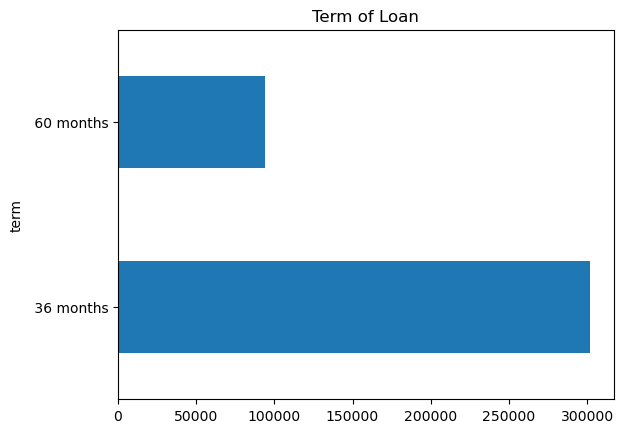

In [10]:
barplot_h(data['term'], Title='Term of Loan')
# only two types of loan - for 36 months and for 60. Can leave as two categories

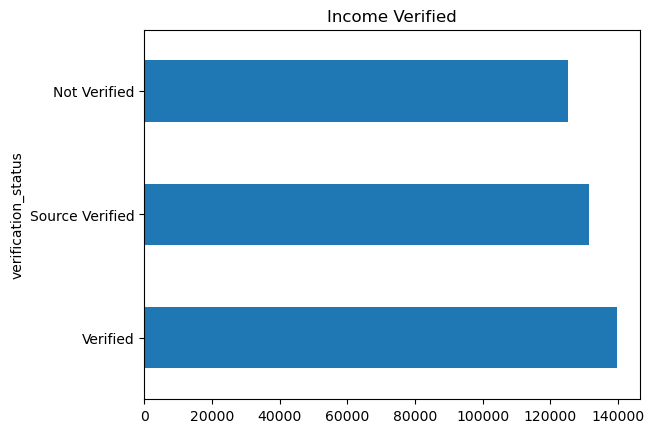

In [11]:
barplot_h(data['verification_status'], Title='Income Verified')

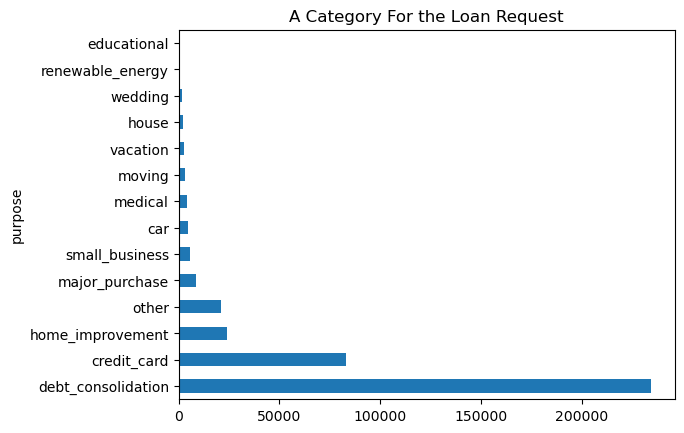

In [12]:
barplot_h(data['purpose'], Title='A Category For the Loan Request')

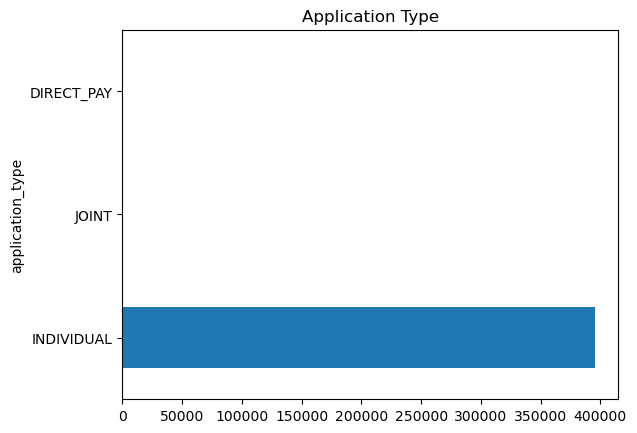

In [13]:
barplot_h(data['application_type'], Title='Application Type')

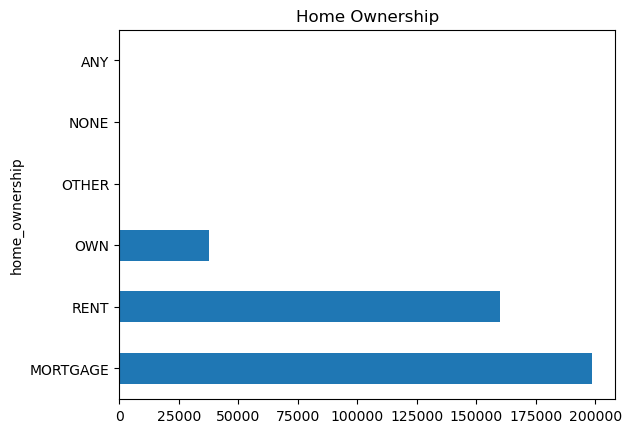

In [14]:
barplot_h(data['home_ownership'], Title='Home Ownership')

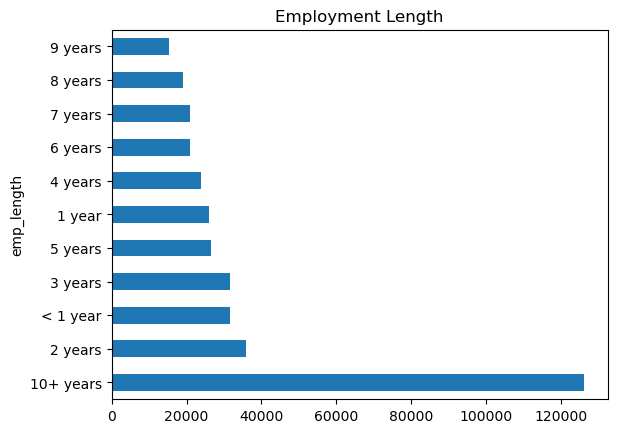

In [15]:
barplot_h(data['emp_length'], Title='Employment Length')

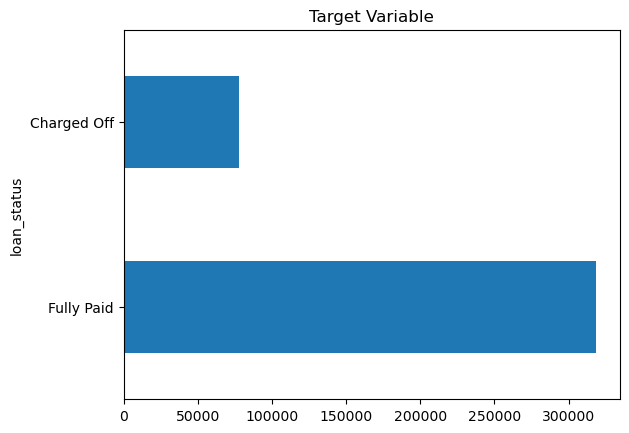

In [16]:
barplot_h(data['loan_status'], Title='Target Variable')

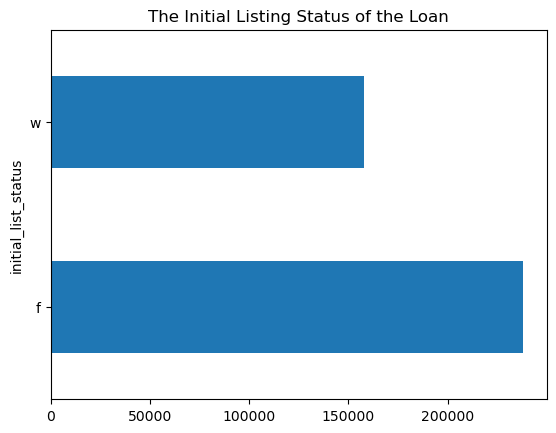

In [17]:
barplot_h(data['initial_list_status'], Title='The Initial Listing Status of the Loan')

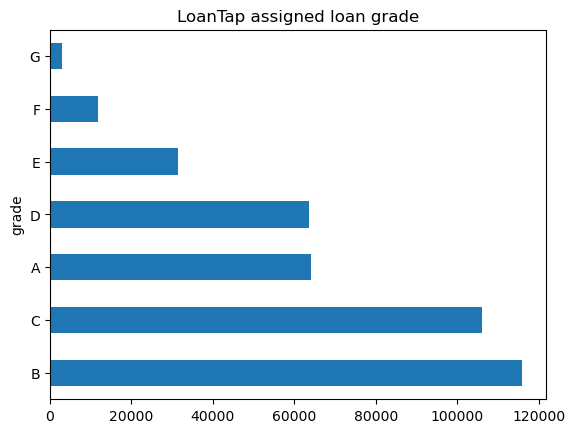

In [18]:
barplot_h(data['grade'], Title='LoanTap assigned loan grade')

I can confidently leave *address*, *emp_title*, and *title* out of scope due to their high cardinality. I will also exclude *grade* and *sub_grade* because these categories are assigned by the company itself, as well as *application_type*, since all applications are from individuals.

## 4. Datetime Variables
I will change the data type of the datetime variables *issue_d* and *earliest_cr_line*. Currently, they are stored as *object* types.

In [19]:
data['issue_d'] = pd.to_datetime(data['issue_d'], format='%b-%Y')
data['earliest_cr_line'] = pd.to_datetime(data['earliest_cr_line'], format='%b-%Y')
data[['issue_d', 'earliest_cr_line']].head()

,issue_d,earliest_cr_line
0,2015-01-01,1990-06-01
1,2015-01-01,2004-07-01
2,2015-01-01,2007-08-01
3,2014-11-01,2006-09-01
4,2013-04-01,1999-03-01


For my analysis, it would be useful to create a delta variable between two dates - the loan issue date and the earliest credit line date.

In [20]:
data['delta_issue_earliest'] = (data['issue_d'] - data['earliest_cr_line']).dt.days
data['delta_issue_earliest'].head()

0    8980
1    3836
2    2710
3    2983
4    5145
Name: delta_issue_earliest, dtype: int64

## 5. Numerical Variables
As for the numerical variables, at this stage I will only check for high correlation coefficients between them in order to exclude variables that are effectively the same predictor.

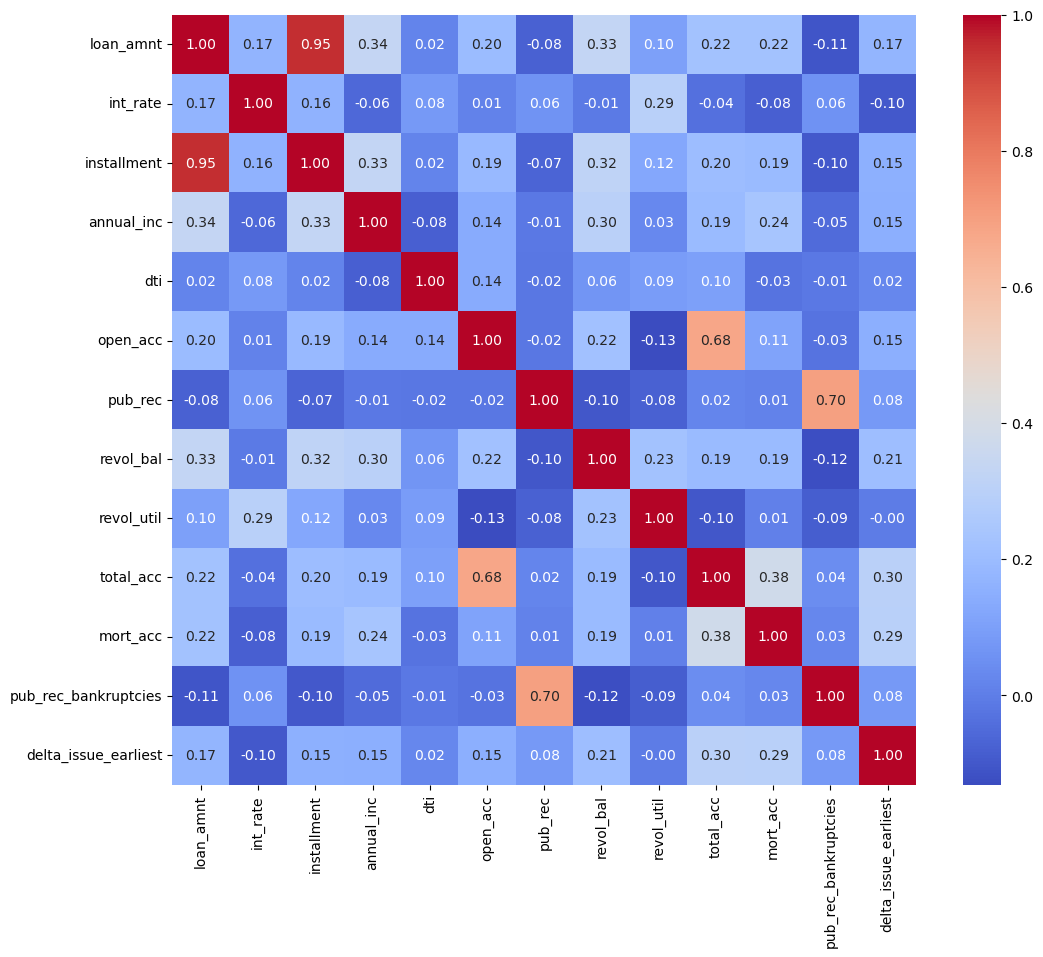

In [21]:
plt.figure(figsize=(12, 10))
correlation = data[['loan_amnt', 'int_rate', 'installment', 'annual_inc', 
                 'dti', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util',
                 'total_acc', 'mort_acc', 'pub_rec_bankruptcies', 'delta_issue_earliest']].corr()

sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f')
plt.show()

The *installment* and *loan_amnt* variables are highly correlated, which makes sense as they convey the same idea - the size of the credit. I will remove *installment* from the analysis.

## 6. Target Variable Encoding

I encode the target variable *loan_status* from a string data type into 0/1 values, which are more suitable for machine learning algorithms.

In [22]:
data['loan_status'] = data['loan_status'].map({'Fully Paid': 0, 'Charged Off': 1})

## 7. Downloading the Cleaned Dataset

As a result of this initial data exploration, I decided to retain 18 variables (12 numerical and 6 categorical) as potential features for modelling, compared to the initial 26 data columns.

In [23]:
data_cleaned = data[['loan_status', #target
                     'loan_amnt', 'int_rate', 'annual_inc','dti', 'open_acc', 'pub_rec', 'revol_bal', 
                     'revol_util', 'total_acc', 'mort_acc', 'pub_rec_bankruptcies', 'delta_issue_earliest', #12 numerical
                     'term', 'emp_length', 'home_ownership', 'verification_status', 'purpose', 'initial_list_status']] #6 categorical

Now I delete all entries with *null* values. The data loss is 55,253 rows, which is about 14%.

In [24]:
data_cleaned = data_cleaned.dropna()
data_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 340775 entries, 0 to 396028
Data columns (total 19 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   loan_status           340775 non-null  int64  
 1   loan_amnt             340775 non-null  float64
 2   int_rate              340775 non-null  float64
 3   annual_inc            340775 non-null  float64
 4   dti                   340775 non-null  float64
 5   open_acc              340775 non-null  float64
 6   pub_rec               340775 non-null  float64
 7   revol_bal             340775 non-null  float64
 8   revol_util            340775 non-null  float64
 9   total_acc             340775 non-null  float64
 10  mort_acc              340775 non-null  float64
 11  pub_rec_bankruptcies  340775 non-null  float64
 12  delta_issue_earliest  340775 non-null  int64  
 13  term                  340775 non-null  object 
 14  emp_length            340775 non-null  object 
 15  home_

In [25]:
data_cleaned.head()

,loan_status,loan_amnt,int_rate,annual_inc,dti,open_acc,pub_rec,revol_bal,revol_util,total_acc,mort_acc,pub_rec_bankruptcies,delta_issue_earliest,term,emp_length,home_ownership,verification_status,purpose,initial_list_status
0,0,10000.0,11.44,117000.0,26.24,16.0,0.0,36369.0,41.8,25.0,0.0,0.0,8980,36 months,10+ years,RENT,Not Verified,vacation,w
1,0,8000.0,11.99,65000.0,22.05,17.0,0.0,20131.0,53.3,27.0,3.0,0.0,3836,36 months,4 years,MORTGAGE,Not Verified,debt_consolidation,f
2,0,15600.0,10.49,43057.0,12.79,13.0,0.0,11987.0,92.2,26.0,0.0,0.0,2710,36 months,< 1 year,RENT,Source Verified,credit_card,f
3,0,7200.0,6.49,54000.0,2.60,6.0,0.0,5472.0,21.5,13.0,0.0,0.0,2983,36 months,6 years,RENT,Not Verified,credit_card,f
4,1,24375.0,17.27,55000.0,33.95,13.0,0.0,24584.0,69.8,43.0,1.0,0.0,5145,60 months,9 years,MORTGAGE,Verified,credit_card,f


In [26]:
data_cleaned.to_csv('data_cleaned.csv', sep=',', index=False)